<a href="https://colab.research.google.com/github/lshofsl/EngramNCA/blob/main/EngramNCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EngramNCA**

In [1]:
#@title Get Packages and Images  { vertical-output: true}

!pip install git+https://github.com/lshofsl/EngramNCA
!git clone --depth 1 --filter=blob:none --sparse https://github.com/lshofsl/EngramNCA.git
!cd EngramNCA/ && git sparse-checkout set Images
!mkdir Images && mv EngramNCA/Images/* Images && rm -rf EngramNCA

  Cloning https://github.com/lshofsl/EngramNCA to /tmp/pip-req-build-jpe2i_hi
  Running command git clone --filter=blob:none --quiet https://github.com/lshofsl/EngramNCA /tmp/pip-req-build-jpe2i_hi
  Resolved https://github.com/lshofsl/EngramNCA to commit 68ebbdc2aeea6646f26879ff142c5b3b8a8b68ec
  Preparing metadata (setup.py) ... done
fatal: destination path 'EngramNCA' already exists and is not an empty directory.
mkdir: cannot create directory ‘Images’: File exists


In [ ]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA.NCA import *
import NCA.utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)




Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 30 #@param {type:"integer"}
WIDTH = 30 #@param {type:"integer"}
CHANNELS = 22 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
RECURRENT_CHANNELS = 3 #@param {type:"integer"} <-- Number of channels for RA computation, these channels are not updated by the NCA and are only used for recurrent processing
MODULATORY_OUTPUT = 3 #@param {type:"integer"} <-- Number of channels for modulatory output, these channels are not updated  and only show the output of the NCA
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size
PRIMITIVES_SHAPES = ["Images/square.png", "Images/circle.png", "Images/triangle.png"]
PRIMITIVES_BODY_PARTS = ["Images/Torso.png", "Images/Head.png", "Images/Tail.png", "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", 'Images/leg4.png']
PRIMITIVES_LINES = ["Images/horizontal.png", "Images/Verical.png"]
style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

paths = PRIMITIVES_SHAPES #@param {type:"string"}
images = []
images_to_display = []
for path in paths:
    image, image_to_display = utils.get_image(path, HEIGHT, WIDTH, padding=PADDING)
    images.append(image)
    images_to_display.append(image_to_display)

genes = [[0], [1], [2]] # <-- Gene one hot encoding, indicates which bits if the gene sequence for each encoded "image" should be 1, [0] = 001, [0,1] = 011, [2] = 100 etc. for 3 bits genes. One, one-hot encoding per image, this rule applies for any gene size

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING
assert len(paths) == len(genes), 'Genes and images should have the same length '

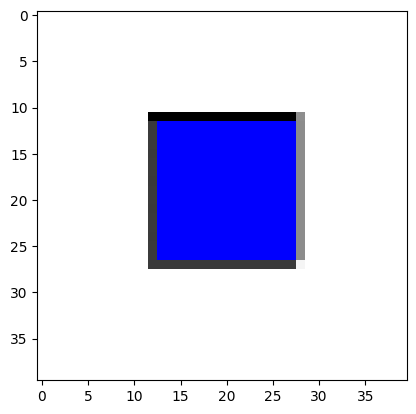

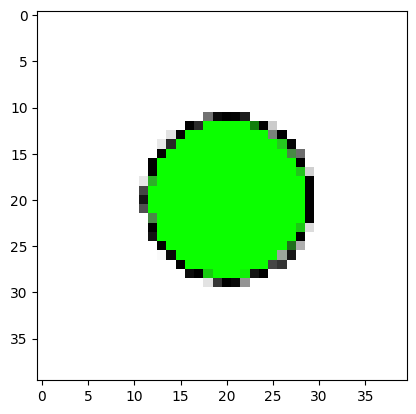

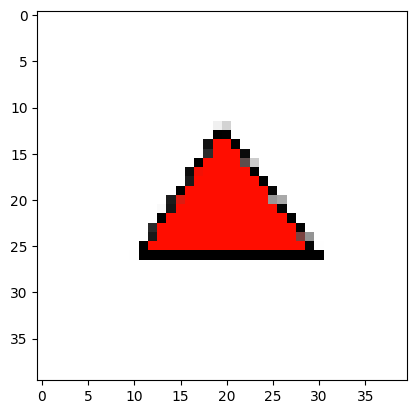

In [5]:
#@title Display Primitives { vertical-output: true}
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    plt.imshow(image)
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, pool_size=POOL_SIZE,height=HEIGHT, width=WIDTH, channels=CHANNELS, gene_size=GENE_COUNT, device=DEVICE))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [6]:
#@title Get Batch Image Partitions { vertical-output: true}
partitions = len(paths)
if partitions == 1:
    part = [BATCH_SIZE]
div = BATCH_SIZE//partitions
rem = BATCH_SIZE % partitions
part = [div + 1 if i < rem else div for i in range(partitions)]
print(f"Batch image paritions = {part}. Batch Size of {BATCH_SIZE}. Number of Partitions = {partitions}")

Batch image paritions = [4, 4, 4]. Batch Size of 12. Number of Partitions = 3


In [7]:
#@title Load Filters for Loss Function { vertical-output: true}
sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [8]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene already exists, all OK!


In [9]:
#@title Initialise NCA { vertical-output: true}
bases = [images[i].tile(part[i],1,1,1) for i in range(len(part))]
base = torch.cat(bases, dim =0 ).to(DEVICE)
loss_log = []
nca = GeneCA(CHANNELS,HIDDEN_SIZE, gene_size=GENE_COUNT)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__ + "_gene_size_" +str(GENE_COUNT)

In [ ]:


#@title Training { vertical-output: true}
for i in range(TRAINING_ITERS + 1):
    loss = 0
    with torch.no_grad():
        idxs, x = utils.get_gene_pool(pools, part, seeds)

    for _ in range( random.randrange(32,92)):
        x = nca(x)
    loss = (base - x[:, :4, :, :]).pow(2).sum() + 0.1 *(perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters) ).pow(2).sum()
    with torch.no_grad():
        loss.backward()
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()

        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        pools = utils.udate_gene_pool(pools, x.clone().detach(), idxs, part)
    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        print("Batch")
        utils.show_batch(x[2:10])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)
    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")


     


TypeError: GeneCA.forward() got an unexpected keyword argument 'step'

In [ ]:
del nca
del optim
torch.cuda.empty_cache()

In [ ]:
#EXPERIMENT

In [ ]:
#Experiment: How much import the number of channels


channel_configs = [16, 20, 24, 30]
results = {}

TRAINING_ITERS = 5000
GENE_COUNT = 8

for C in channel_configs:
    print(f"\n--- Starting Experiment with {C} Channels ---")

    # 1. Setup Base Target
    bases = [images[i].tile(part[i], 1, 1, 1) for i in range(len(part))]
    base = torch.cat(bases, dim=0).to(DEVICE)

    # 2. Reset Model & Optimizer for new channel size
    nca = GeneCA(C, HIDDEN_SIZE, gene_size=GENE_COUNT).to(DEVICE)
    optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1000, gamma=0.3)

    # 3. CRUCIAL: Re-initialize pool to match NEW channel count C
    # Replace 'POOL_SIZE', 'HEIGHT', 'WIDTH' with your variables
    pools = torch.zeros((POOL_SIZE, C, HEIGHT, WIDTH), device=DEVICE)

    loss_log = []

    pools = []
    for gene in genes:
        pools.append(utils.make_gene_pool(
                gene_location=gene,
                pool_size=POOL_SIZE,
                height=HEIGHT,
                width=WIDTH,
                channels=C,
                gene_size=GENE_COUNT,
                device=DEVICE
            ))
    seeds = []
    for pool in pools:
        seeds.append(pool[0].clone())

    for i in range(TRAINING_ITERS + 1):
        # A. Get data from pool

        with torch.no_grad():
            idxs, x = utils.get_gene_pool(pools, part, seeds)

        # B. Growth
        for _ in range(random.randrange(32, 92)):
            x = nca(x)

        # C. Loss Calculation
        loss = (base - x[:, :4, :, :]).pow(2).sum() + \
               0.1 * (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).sum()

        # D. Backprop (Outside of no_grad!)
        optim.zero_grad()
        loss.backward()

        # E. Grad Norm & Step
        with torch.no_grad():
            for p in nca.parameters():
                p.grad /= (p.grad.norm() + 1e-8)

        optim.step()
        scheduler.step()

        # F. Log and Update Pool
        loss_log.append(loss.log().item())

        with torch.no_grad():
            # Standardize on 'update_gene_pool' (check your spelling: udate vs update)
            pools = utils.udate_gene_pool(pools, x.detach(), idxs, part)

        if i % 500 == 0:
            print(f"[{C} Channels] Iter {i}, Loss: {loss.item():.4f}")

    results[C] = loss_log
    torch.save(nca.state_dict(), f"Trained_models/Experiment_C{C}.pth")

    del nca
    del optim
    torch.cuda.empty_cache()

print("\n--- All Experiments Complete ---")

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('NCA Performance: Channel Count Comparison')

for C, log in results.items():
    # We apply a small rolling average to make the lines smoother/readable
    smooth_log = [sum(log[max(0, j-20):j+1])/len(log[max(0, j-20):j+1]) for j in range(len(log))]
    plt.plot(smooth_log, label=f'{C} Channels')

plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
channel_configs = [16, 24, 32]
gene_configs = [6, 8, 10]
grid_results = []

for G in gene_configs:
    for C in channel_configs:
        print(f"Testing: Channels={C}, Gene Size={G}")

        # 1. Setup Base Target
        bases = [images[i].tile(part[i], 1, 1, 1) for i in range(len(part))]
        base = torch.cat(bases, dim=0).to(DEVICE)

        # 2. Reset Model - Use G, not GENE_COUNT
        nca = GeneCA(C, HIDDEN_SIZE, gene_size=G).to(DEVICE)
        optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1000, gamma=0.3)

        # 3. Initialize pools using the correct C and G
        pools = []
        for i_gene in range(len(genes)):
            pools.append(utils.make_gene_pool(
                gene_location=genes[i_gene],
                pool_size=POOL_SIZE,
                height=HEIGHT,
                width=WIDTH,
                channels=C,
                gene_size=G,
                device=DEVICE
            ))

        seeds = [p[0].clone() for p in pools]
        loss_log = []
        final_loss_sum = 0

        # --- TRAINING LOOP START ---
        for i in range(2000 + 1):
            # A. Get data
            with torch.no_grad():
                idxs, x = utils.get_gene_pool(pools, part, seeds)

            # B. Growth (Now correctly inside the loop)
            for _ in range(random.randrange(32, 92)):
                x = nca(x)

            # C. Loss
            loss = (base - x[:, :4, :, :]).pow(2).sum() + \
                   0.1 * (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).sum()

            # D. Backprop
            optim.zero_grad()
            loss.backward()

            # E. Grad Norm
            with torch.no_grad():
                for p in nca.parameters():
                    p.grad /= (p.grad.norm() + 1e-8)

            optim.step()
            scheduler.step()

            # F. Pool Update - using 'udate_gene_pool' per your utils.py
            with torch.no_grad():
                pools = utils.udate_gene_pool(pools, x.detach(), idxs, part)

            # Collect average loss for the last 100 steps
            if i > 1900:
                final_loss_sum += loss.item()

            if i % 500 == 0:
                print(f"Iter {i}, Loss: {loss.item():.4f}")
        # --- TRAINING LOOP END ---

        grid_results.append((C, G, final_loss_sum / 100))

        del nca, optim
        torch.cuda.empty_cache()

print("\n--- All Experiments Complete ---")

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert your results to a DataFrame
df = pd.DataFrame(grid_results, columns=['Channels', 'GeneSize', 'Loss'])

# Save to CSV (Always a good idea for your thesis records!)
df.to_csv("grid_search_results.csv", index=False)


plt.figure(figsize=(10, 6))

# Sort to ensure lines are drawn correctly
df = df.sort_values(by=['GeneSize', 'Channels'])

# Create a line for each Gene Size configuration
for gene_size in sorted(df['GeneSize'].unique()):
    subset = df[df['GeneSize'] == gene_size]
    plt.plot(subset['Channels'], subset['Loss'], marker='o', label=f'Gene Size: {gene_size}')

plt.title('NCA Performance: Impact of Channels and Gene Size (lizard)', fontsize=14)
plt.xlabel('Number of Channels (C)', fontsize=12)
plt.ylabel('Final Loss (MSE)', fontsize=12)
plt.xticks(channel_configs)  # Show only the tested channel counts
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Complexity (G)")
plt.show()

In [ ]:
#@title Video Utils { vertical-output: true}
path_video = "Saved_frames/GeneCA"

if not os.path.exists(path_video):
    os.makedirs(path_video)
    print(f"Path: {path_video} created")
else:
    print(f"Path: {path_video} already exists, all OK!")

def write_frame(x, path, frame_number, height, width, chn):
  image_np = x.clone().detach().cpu().permute(0,2,3,1).numpy().clip(0,1)[0,:,:,:3]
  plt.imsave(f"{path}/frame_{frame_number}.png", image_np)

def make_video(path, total_frames, height, width):
    # 'VP80' is the standard codec for WebM files
    fourcc = cv2.VideoWriter_fourcc(*'VP80')

    # Save as .webm
    video_filename = os.path.join(path, 'output_video.webm')

    # Ensure (width, height) matches your frame dimensions exactly
    out = cv2.VideoWriter(video_filename, fourcc, 30.0, (width, height))

    for frame_number in range(total_frames):
        frame_path = os.path.join(path, f"frame_{frame_number}.png")
        frame = cv2.imread(frame_path)

        if frame is not None:
            # Critical: Resize if the image doesn't match the VideoWriter setup
            if (frame.shape[1], frame.shape[0]) != (width, height):
                frame = cv2.resize(frame, (width, height))

            out.write(frame)
        else:
            print(f"Warning: Could not read {frame_path}")

    out.release()
    print(f"WebM video saved to: {video_filename}")

def place_seed(x, center_x, center_y, seeds, seed_index):
    x[:,3:-8,center_x,center_y] = 1
    x[:,-4:,center_x,center_y] = seeds[seed_index]
    return x

In [ ]:
#@title Create Video { vertical-output: true}
#del nca
#del optim
torch.cuda.empty_cache()
seeds = []
seeds = [torch.tensor([0.0,0.0,0.0,1.0], device=DEVICE),torch.tensor([0.0,0.0,1.0,0.0], device=DEVICE),
         torch.tensor([0.0,1.0,0.0,0.0], device=DEVICE), torch.tensor([0.0,1.0,0.0,1.0], device=DEVICE),
         torch.tensor([0.0,1.0,1.0,0.0], device=DEVICE),torch.tensor([0.0,1.0,1.0,1.0], device=DEVICE), torch.tensor([0.0,0.0,1.0,1.0], device=DEVICE)]


# Spaced out to prevent shapes from growing into each other
seed_locs = [[20, 30], [20, 80], [20, 130],[80, 30], [80, 80], [80, 130],[130, 30]]

seed_index = 0

nca = GeneCA(CHANNELS,hidden_n=HIDDEN_SIZE, gene_size=GENE_COUNT)
nca.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth"))
nca.to(DEVICE).eval()
x_prime = torch.zeros((1, CHANNELS, HEIGHT*4, WIDTH*4), device=DEVICE)


frame_count = 499
for i in range(frame_count):
    x_prime = nca(x_prime)
    if i % 50 == 0:
        place_seed(x_prime, seed_locs[seed_index][0], seed_locs[seed_index][1], seeds, seed_index)
        seed_index = (seed_index + 1) % len(seeds)
    x_prime = x_prime.detach()
    write_frame(x_prime, path_video, i, HEIGHT*4, WIDTH*4,CHANNELS)
make_video(path_video, frame_count, HEIGHT*4, WIDTH*4)


In [ ]:
#@title Display Vide { vertical-output: true}
Video(path_video+'/output_video.webm', embed=True, width=320, height=320)

# **Gene Propogatio CA**

In [ ]:
#@title Setup { vertical-output: true}
#del nca
torch.cuda.empty_cache()
HEIGHT = 60 #@param {type:"integer"}
WIDTH = 60 #@param {type:"integer"}
BATCH_SIZE = 10 #@param {type:"integer"}
SQUARE = ['Images/square.png']
LIZARD = [ "Images/lizard.png"]
BUTTERFLY = [ "Images/BUTTERFLY.png"]
SPIDER = [ "Images/spider.png"]
MULTIPLE = ["Images/lizard.png","Images/spider.png" ] #<-- add multiple path for training multiple NCA morphologies into one
TRAINING_ITERS = 14000 #@param {type:"integer"}
HIDDEN_SIZE_PROP = 128 #@param {type:"integer"}
PADDING = 0 #@param {type:"integer"}


In [ ]:
#@title Load Image { vertical-output: true}
paths = LIZARD  #@param {type:"string"}
images = []
images_to_display = []
for path in paths:
    image, image_to_display = utils.get_image(path, HEIGHT, WIDTH, padding=PADDING)
    images.append(image)
    images_to_display.append(image_to_display)
genes = [[1]]
HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING
assert len(paths) == len(genes), 'Genes and images should have the same length '

In [ ]:
#@title Display Image { vertical-output: true}
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    plt.imshow(image)
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, pool_size= 1000, height=HEIGHT, width=WIDTH, channels=CHANNELS, gene_size=8,  device=DEVICE))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [ ]:
#@title Get Batch Image Partition { vertical-output: true}
partitions = len(paths)
if partitions == 1:
    part = [BATCH_SIZE]
div = BATCH_SIZE//partitions
rem = BATCH_SIZE % partitions
part = [div + 1 if i < rem else div for i in range(partitions)]
print(f"Batch image paritions = {part}. Batch Size of {BATCH_SIZE}. Number of Partitions = {partitions}")

In [ ]:
#@title Generate Extra Genes for Multi Morphology GeneProp CA { vertical-output: true}
gene_2 = []
for idx,p in enumerate(part):
    gene = torch.zeros((1,HEIGHT,WIDTH), device=DEVICE)
    gene[:,HEIGHT//2,WIDTH//2] = idx
    gene_2.append(gene.tile(p, 1, 1, 1))
genes = torch.cat(gene_2, dim = 0)

In [ ]:
#@title Create Path for Saving Models { vertical-output: true}
folder = "GeneProp"
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")

In [ ]:
#@title Initialise GeneCA (static) and GeneProp CA for Trainign { vertical-output: true}
bases = [images[i].tile(part[i],1,1,1) for i in range(len(part))]
base = torch.cat(bases, dim =0 ).to(DEVICE)
loss_log = []
with torch.no_grad():
    ncaPre = GeneCA(CHANNELS,hidden_n=64, gene_size=GENE_COUNT)
    ncaPre.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth")) #Saved weights
    ncaPre.to(DEVICE).eval()
nca = GenePropCA(CHANNELS,HIDDEN_SIZE_PROP, gene_size=GENE_COUNT)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=5000, gamma=0.3)
name = folder + "/" +type(nca).__name__ + "_gene_size_" +str(GENE_COUNT)

In [ ]:
#@title Train GeneProp CA { vertical-output: true}
#TODO: Make it so that multi image gene props use the secondary genes
lambda_p = 0.1
lambda_m = 0.1

alpha_log = []
beta_log   = []
omega_log  = []
K_log      = []
kappa_log  = []
log_iters  = []

for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        idxs, x = utils.get_gene_pool(pools, part, seeds)

    # Ensure x is ready for gradients
    x = x.detach().clone()
    x.requires_grad = True

    optim.zero_grad()

    # Initialize loss tensors on the correct device
    total_amp_loss = torch.tensor(0.0, device=x.device)
    total_smooth_loss = torch.tensor(0.0, device=x.device)

    # Use a local list to track states if needed, but avoid modifying 'x' in-place
    current_x = x

    itters = random.randrange(32, 92)
    for t in range(itters):
        m_prev = current_x[:, 18:21].clone()

        current_x = ncaPre(current_x)

        out, phase, amplitud = nca(current_x, step=t, k=4)
        current_x = out

        total_amp_loss += amplitud.pow(2).mean()
        total_smooth_loss += (current_x[:, 18:21] - m_prev).pow(2).mean()

    # Image loss using the final state
    x_rgb = current_x[:, :4, :, :]
    loss_img = (base - x_rgb).pow(2).mean() + \
               0.1 * (perchannel_conv(base, filters) - perchannel_conv(x_rgb, filters)).pow(2).mean()

    loss = loss_img + (lambda_p * total_amp_loss / itters) + (lambda_m * total_smooth_loss / itters)

    loss.backward()

    # Gradient clipping (Stabilizes NCA training)
    for p in nca.parameters():
        if p.grad is not None:
            p.grad /= (p.grad.norm() + 1e-8)

    optim.step()

    # 6. Housekeeping (Use no_grad for memory management)
    loss_log.append(loss.log().item())
    with torch.no_grad():
        # Update pool with detached state so we don't carry the graph
        pools = utils.udate_gene_pool(pools, current_x.detach(), idxs, part)

    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        print(name)
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        utils.show_batch(x[2:10])
        plt.show(block=False)
        plt.pause(0.01)

        alpha_log.append(nca.alpha.item())
        beta_log.append(nca.beta.item())
        omega_log.append(nca.omega.item())
        K_log.append(nca.K.item())
        kappa_log.append(nca.kappa.item())
        log_iters.append(i)


    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")

In [ ]:
del nca
del ncaPre
del optim
torch.cuda.empty_cache()

In [ ]:
#@title Create Video { vertical-output: true}
#del nca
#del ncaPre
#del optim
torch.cuda.empty_cache()
path_video = "Saved_frames/GenePropCA"
if not os.path.exists(path_video):
    os.makedirs(path_video)
    print(f"Path: {path_video} created")
else:
    print(f"Path: {path_video} already exists, all OK!")
seeds = [torch.tensor([0.0,1.0,0.0], device=DEVICE)]
seed_locs = [[30,30]]
seed_index = 0

def place_seed(x, center_x, center_y, seeds, seed_index):
    # Only set alpha=1 at seed location
    x[:, 3, center_x, center_y] = 1.0
    # Set gene channels (12:15) to the gene encoding
    x[:, 12:12+GENE_COUNT, center_x, center_y] = seeds[seed_index]

nca = GeneCA(CHANNELS,hidden_n=HIDDEN_SIZE, gene_size=GENE_COUNT)
nca.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth"))
nca.to(DEVICE).eval()
nca_prop = GenePropCA(CHANNELS,hidden_n=HIDDEN_SIZE_PROP, gene_size=GENE_COUNT)
nca_prop.load_state_dict(torch.load("Trained_models/GeneProp/GenePropCA_gene_size_3.pth"))
nca_prop.to(DEVICE).eval()
x_prime = torch.zeros((1, CHANNELS, HEIGHT, WIDTH), dtype=torch.float32).cuda()
frame_count = 500
for i in range(frame_count):
    x_prime = nca(x_prime)
    x_prime = x_prime.detach()
    if i > 50:
        # Unpack the tuple returned by nca_prop and take only the first element (out)
        x_prime, _, _ = nca_prop(x_prime)
        place_seed(x_prime, seed_locs[seed_index][0], seed_locs[seed_index][1], seeds, seed_index)
        seed_index = (seed_index + 1) % len(seeds)
    write_frame(x_prime, path_video, i, HEIGHT*3, WIDTH*3,CHANNELS)
make_video(path_video, frame_count, HEIGHT*3, WIDTH*3)

In [ ]:
#@title Display Vide { vertical-output: true}
Video(path_video+'/output_video.webm', embed=True, width=320, height=320)

In [ ]:
nca = GeneCA(CHANNELS,hidden_n=HIDDEN_SIZE, gene_size=GENE_COUNT)
nca.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth"))
nca.to(DEVICE).eval()
nca_prop = GenePropCA(CHANNELS,hidden_n=HIDDEN_SIZE_PROP, gene_size=GENE_COUNT)
nca_prop.load_state_dict(torch.load("Trained_models/GeneProp/GenePropCA_gene_size_3.pth"))
nca_prop.to(DEVICE).eval()

In [ ]:
with torch.no_grad():
    # Start from a pool sample — guaranteed good starting state
    x_test = pools[0][0:1].clone().to(DEVICE)

    # Grow for 100 steps
    for t in range(500):
        x_test = ncaPre(x_test)
        x_test, phase, amp = nca_prop(x_test, step=t, k=4)

    # --- Plot 1: What it looks like after growth ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x_test[0, :4].permute(1,2,0).cpu().clip(0,1))
    axes[0].set_title('RGBA after 100 steps')
    axes[1].imshow(x_test[0, 15].cpu(), cmap='RdBu')
    axes[1].set_title('RA: a')
    axes[2].imshow(x_test[0, 16].cpu(), cmap='RdBu')
    axes[2].set_title('RA: b')
    axes[3].imshow(x_test[0, 17].cpu(), cmap='hot')
    axes[3].set_title('RA: d (injury field)')
    plt.suptitle('RA spatial organization after growth')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Damage experiment ---
    x_damaged = x_test.clone()
    x_damaged[:, :, :, x_damaged.shape[3]//2:] = 0  # remove right half

    amps, losses = [], []
    frames_damaged = [x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)]

    for t in range(200):
        x_damaged = ncaPre(x_damaged)
        x_damaged, phase, amp = nca_prop(x_damaged, step=t, k=4)
        amps.append(amp.mean().item())
        losses.append((base[0:1] - x_damaged[:, :4]).pow(2).mean().item())
        if t in [25, 50, 100, 150, 199]:
            frames_damaged.append(
                x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)
            )

    # Show regeneration frames
    fig, axes = plt.subplots(1, len(frames_damaged), figsize=(20, 4))
    titles = ['damage'] + [f't={t}' for t in [25, 50, 100, 150, 199]]
    for ax, frame, title in zip(axes, frames_damaged, titles):
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle('Regeneration after damage (right half removed)')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: RA amplitude and loss over regeneration ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    ax1.plot(amps)
    ax1.axvline(x=0, color='r', linestyle='--', label='damage applied')
    ax1.set_title('RA mean amplitude ρ during regeneration')
    ax1.set_ylabel('mean ρ')
    ax1.legend()
    ax2.plot(losses)
    ax2.set_title('Reconstruction loss during regeneration')
    ax2.set_ylabel('MSE')
    ax2.set_xlabel('step after damage')
    plt.tight_layout()
    plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learned RA parameter evolution', fontsize=14)

# --- α and ω: ring geometry ---
ax = axes[0, 0]
ax.plot(log_iters, alpha_log, label='α (radial damping)', color='purple')
ax.plot(log_iters, omega_log, label='ω (frequency)',      color='teal')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Ring attractor geometry')
ax.set_xlabel('training iteration')
ax.legend()

# --- β, K, κ: diffusion and coupling ---
ax = axes[0, 1]
ax.plot(log_iters, beta_log,  label='β (d decay)',          color='orange')
ax.plot(log_iters, K_log,     label='K (spatial coupling)', color='blue')
ax.plot(log_iters, kappa_log, label='κ (d diffusion)',      color='green')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Diffusion and coupling')
ax.set_xlabel('training iteration')
ax.legend()

# --- r* = sqrt(max(α,0)): learned ring radius ---
ax = axes[1, 0]
r_star = [np.sqrt(max(a, 0)) for a in alpha_log]
ax.plot(log_iters, r_star, color='purple', linestyle='--')
ax.set_title('Implied ring radius  r* = √max(α,0)')
ax.set_xlabel('training iteration')
ax.set_ylabel('r*')

# --- κ/β ratio: spatial coherence length of d ---
ax = axes[1, 1]
coherence = [k / (b + 1e-8) for k, b in zip(kappa_log, beta_log)]
ax.plot(log_iters, coherence, color='green')
ax.axhline(1, color='gray', linewidth=0.7, linestyle='--', label='κ/β = 1')
ax.set_title('Spatial coherence of d  (κ/β ratio)')
ax.set_xlabel('training iteration')
ax.set_ylabel('κ / β')
ax.legend()

plt.tight_layout()
plt.savefig('ra_parameter_evolution.png', dpi=150)
plt.show()

# Numerical summary at convergence
print("=== Converged parameter values ===")
print(f"  α = {alpha_log[-1]:.4f}  {'✓ stable ring' if alpha_log[-1] > 0 else '✗ unstable — consider softplus constraint'}")
print(f"  ω = {omega_log[-1]:.4f}  {'✓ rotating' if abs(omega_log[-1]) > 1e-3 else '✗ frozen phase'}")
print(f"  β = {beta_log[-1]:.4f}")
print(f"  K = {K_log[-1]:.4f}")
print(f"  κ = {kappa_log[-1]:.4f}")
print(f"  r* = {r_star[-1]:.4f}")
print(f"  κ/β = {coherence[-1]:.4f}")

In [ ]:
with torch.no_grad():
    # Correlation between d field and alpha channel
    alpha = x_vis[0, 3].cpu().numpy().flatten()
    d_field = x_vis[0, 17].cpu().numpy().flatten()

    correlation = np.corrcoef(alpha, d_field)[0,1]
    print(f"Correlation between alpha and d field: {correlation:.4f}")

    # Also check correlation with distance from center
    H, W = x_vis.shape[2], x_vis.shape[3]
    yy, xx = np.mgrid[0:H, 0:W]
    dist_from_center = np.sqrt((yy - H//2)**2 + (xx - W//2)**2).flatten()

    corr_dist = np.corrcoef(dist_from_center, d_field)[0,1]
    print(f"Correlation between d field and distance from center: {corr_dist:.4f}")